In [1]:
from pathlib import Path
from glob import glob
import random

# --- 1. ОПРЕДЕЛЯЕМ ПУТИ НА ОСНОВЕ ВАШЕГО СКРИНШОТА ---
# Ваши папки называются train_opus и test_opus
TRAIN_DIR_NAME = "train_opus"
TEST_DIR_NAME = "test_opus"

train_dir = Path(TRAIN_DIR_NAME)
test_dir = Path(TEST_DIR_NAME)

# --- 2. ПРОВЕРЯЕМ, ЧТО ПАПКИ СУЩЕСТВУЮТ ---
if not train_dir.is_dir():
    raise FileNotFoundError(
        f"Не найдена директория '{TRAIN_DIR_NAME}'. Убедитесь, что она находится в той же папке, что и ноутбук."
    )
if not test_dir.is_dir():
    raise FileNotFoundError(
        f"Не найдена директория '{TEST_DIR_NAME}'. Убедитесь, что она находится в той же папке, что и ноутбук."
    )

print(f"✅ Найдена тренировочная папка: {train_dir.resolve()}")
print(f"✅ Найдена тестовая папка:     {test_dir.resolve()}")

# --- 3. САМЫЙ НАДЕЖНЫЙ ПОИСК ФАЙЛОВ (РЕКУРСИВНЫЙ) ---
# Ищем все файлы .opus во всех подпапках. Это найдет файлы,
# где бы они ни лежали: прямо в 'train_opus/' или в 'train_opus/audio/'.
print("\nИщем аудиофайлы...")
train_files = sorted(glob(str(train_dir / "**" / "*.opus"), recursive=True))
test_files = sorted(glob(str(test_dir / "**" / "*.opus"), recursive=True))

# На всякий случай фильтруем "мусорные" файлы macOS, если они есть
train_files = [f for f in train_files if not Path(f).name.startswith('._')]
test_files = [f for f in test_files if not Path(f).name.startswith('._')]

if not train_files:
    raise FileNotFoundError(f"Внутри папки '{TRAIN_DIR_NAME}' не найдено ни одного файла .opus!")

print(f"✅ Найдено тренировочных файлов: {len(train_files)}")
print(f"✅ Найдено тестовых файлов:      {len(test_files)}")

# --- 4. ПРЕВЬЮ НАЙДЕННЫХ ФАЙЛОВ ---
def _preview(files_list, n=5):
    if not files_list: return "файлы не найдены"
    stems = sorted([Path(p).stem for p in files_list])
    random.seed(42)
    return sorted(random.sample(stems, min(n, len(stems))))

print("\nПримеры id из train:", _preview(train_files, 5))
print("Примеры id из test :", _preview(test_files, 5))

✅ Найдена тренировочная папка: /home/kostia/task_A/train_opus
✅ Найдена тестовая папка:     /home/kostia/task_A/test_opus

Ищем аудиофайлы...
✅ Найдено тренировочных файлов: 90000
✅ Найдено тестовых файлов:      27000

Примеры id из train: ['0364902065799355474407447255462668296389', '1586861873834120691362543557009999684973', '3541057813519965625325984265723027926548', '3997242737614642235545383728748091631413', '9305667343808054924938806177554472693123']
Примеры id из test : ['0310935140366809590120322340182793108872', '1392463355791196318582814783595425618374', '3355968993770863785809779652117442152265', '7749220871310417411407320119861423317991', '8989614132124256217701763003882797236296']


In [2]:
NUM_EPOCHS = 5
RANDOM_STATE=42
TEST_SIZE=0.2
KEYWORD1 = "не слышу"
KEYWORD2 = "не слышно"



--- Пример файла из тренировочного набора ---


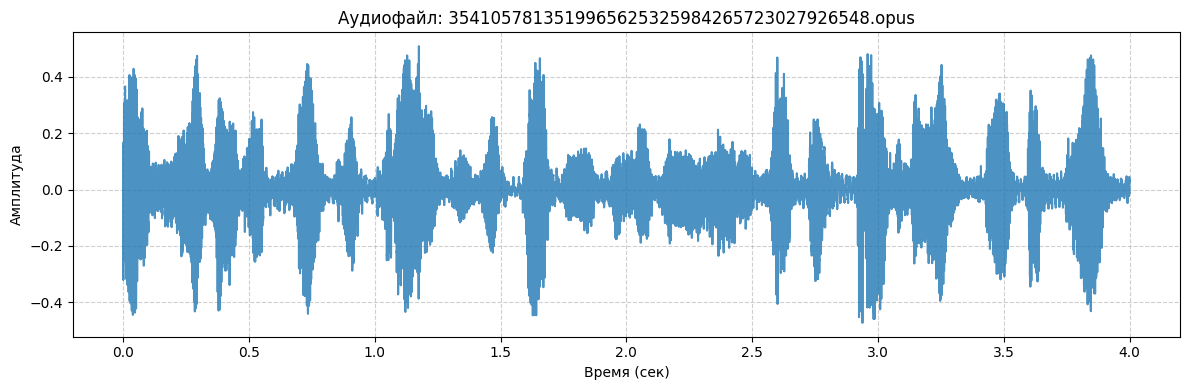

Прослушать 3541057813519965625325984265723027926548.opus (длительность 4.00 с, sr=16000)



--- Пример файла из тестового набора ---


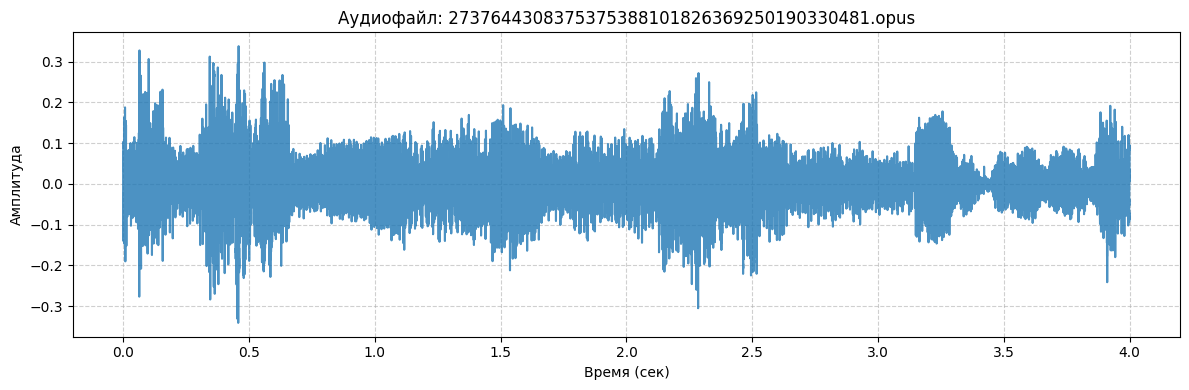

Прослушать 2737644308375375388101826369250190330481.opus (длительность 4.00 с, sr=16000)


In [3]:
from IPython.display import Audio, display
import librosa
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import soundfile as sf


def safe_load_audio(path, sr_target=16000):
    """
    Безопасно загружаем аудио. Пытаемся использовать librosa,
    при неудаче fallback на soundfile.
    """
    try:
        audio, sr = librosa.load(path, sr=sr_target)
    except Exception:
        data, sr = sf.read(path, dtype="float32", always_2d=False)
        if sr != sr_target:
            audio = librosa.resample(data, orig_sr=sr, target_sr=sr_target)
            sr = sr_target
        else:
            audio = data
    return audio, sr

def plot_audio_sample(file_path: str, sr_target: int = 16000, play: bool = True):
    """
    Визуализирует и при необходимости воспроизводит аудиофайл.
    Версия, которая не требует файла разметки word_bounds.
    """
    file_path = Path(file_path)
    
    try:
        # librosa.load сразу загрузит, сделает моно и ресемплирует до 16кГц
        audio, sr = librosa.load(file_path, sr=sr_target, mono=True)
    except Exception as e:
        print(f"Не удалось загрузить {file_path.name}: {e}")
        return

    duration = len(audio) / sr

    # --- Визуализация ---
    plt.figure(figsize=(12, 4))
    time = np.linspace(0, duration, len(audio))
    plt.plot(time, audio, alpha=0.8)
    plt.title(f"Аудиофайл: {file_path.name}")
    plt.xlabel("Время (сек)")
    plt.ylabel("Амплитуда")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # --- Прослушивание ---
    if play:
        print(f"Прослушать {file_path.name} (длительность {duration:.2f} с, sr={sr})")
        display(Audio(audio, rate=sr))

# --- Показываем примеры ---

# Убедимся, что списки файлов не пустые, прежде чем пытаться что-то из них взять
if train_files:
    print("--- Пример файла из тренировочного набора ---")
    # Берем случайный файл из списка для разнообразия
    random_train_file = random.choice(train_files)
    plot_audio_sample(random_train_file)
else:
    print("⚠️ Тренировочные файлы не найдены, невозможно показать пример.")

if test_files:
    print("\n--- Пример файла из тестового набора ---")
    random_test_file = random.choice(test_files)
    plot_audio_sample(random_test_file)
else:
    print("\n⚠️ Тестовые файлы не найдены, невозможно показать пример.")

In [4]:
import torch
import librosa
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import gigaam
import warnings
import os
from pathlib import Path

# --- добавлено для обработки текста v4 ---
import re
import unicodedata
import soundfile as sf  # для sf.write

AUDIO_FOLDER_PATH = Path("./test_opus/audio/")
SUBMISSION_FILENAME = "submission.csv"
KEYWORDS = ["не слышно", "не слышу", "неслышно", "неслышу"]
MODEL_NAME = "v2_ctc"

warnings.filterwarnings("ignore", category=UserWarning)

# --- обработка текста v4 ---
def normalize_text_v4(text: str) -> str:
    """
    Нормализует ASR-текст:
    - NFKC нормализация
    - нижний регистр
    - ё -> е
    - базовое приведение похожей латиницы к кириллице
    - удаление пунктуации (в пробелы) и сжатие пробелов
    """
    if not isinstance(text, str):
        text = str(text) if text is not None else ""

    s = unicodedata.normalize("NFKC", text).lower()
    s = s.replace("ё", "е")

    # Простейшее приведение похожей латиницы к кириллице
    latin_to_cyr = str.maketrans({
        "a": "а", "e": "е", "o": "о", "c": "с", "p": "р", "x": "х",
        "y": "у", "k": "к", "m": "м", "t": "т", "h": "н",
    })
    s = s.translate(latin_to_cyr)

    # Убираем пунктуацию -> пробел, затем сжимаем пробелы
    s = re.sub(r"[^\w\s]+", " ", s, flags=re.UNICODE)
    s = re.sub(r"\s+", " ", s).strip()
    return s

RE_NE_SLYSHNO = re.compile(r"\bне\s*слышно\b")
RE_NE_SLYSHU  = re.compile(r"\bне\s*слышу\b")

def find_keywords_in_text_v4(text: str):
    """
    Возвращает список найденных целевых фраз:
    - 'не слышно' (включая 'неслышно' и варианты с лишними пробелами)
    - 'не слышу'  (включая 'неслышу' и варианты с лишними пробелами)
    """
    found = []
    if RE_NE_SLYSHNO.search(text):
        found.append("не слышно")
    if RE_NE_SLYSHU.search(text):
        found.append("не слышу")
    return sorted(set(found))


def find_keywords_in_audio(file_list, model, keywords_to_find):
    """
    Обрабатывает список аудиофайлов, ищет в них ключевые фразы
    и возвращает словарь с найденными совпадениями.
    Использует временные WAV-файлы для надежной работы с любой версией gigaam.
    """
    found_in_files = {}
    temp_wav_file = "temp_audio.wav"  # Имя для временного файла

    for filename in tqdm(file_list, desc="Обработка аудиофайлов"):
        try:
            # --- ШАГ 1: Предобработка и сохранение во временный файл ---
            # Загружаем и нормализуем аудио
            y, sr = librosa.load(str(filename), sr=16000)
            y_normalized = librosa.util.normalize(y)

            # Сохраняем обработанное аудио во временный WAV-файл
            sf.write(temp_wav_file, y_normalized, 16000)

            # --- ШАГ 2: Транскрибация по пути к временному файлу ---
            transcription = model.transcribe(temp_wav_file)

            # --- ШАГ 3: Анализ текста (обработка текста v4) ---
            clean_transcription = normalize_text_v4(transcription)
            found_phrases_in_file = find_keywords_in_text_v4(clean_transcription)

            if found_phrases_in_file:
                unique_phrases = sorted(list(set(found_phrases_in_file)))
                found_in_files[Path(filename).name] = unique_phrases

        except Exception as e:
            print(f"\nОшибка при обработке файла {Path(filename).name}: {e}")
            continue
        finally:
            # --- ШАГ 4: Очистка ---
            if os.path.exists(temp_wav_file):
                os.remove(temp_wav_file)

    return found_in_files


# --- 2. ОСНОВНОЙ БЛОК ИСПОЛНЕНИЯ ---
def main():
    all_opus_files = AUDIO_FOLDER_PATH.glob("*.opus")
    test_files = [f for f in all_opus_files if not f.name.startswith('._')]
    if not test_files:
        print(f"ОШИБКА: В папке '{AUDIO_FOLDER_PATH}' не найдено ни одного .opus файла.")
        return

    print(f"Найдено {len(test_files)} аудиофайлов для обработки.")

    print(f"Загрузка модели '{MODEL_NAME}'...")
    try:
        model = gigaam.load_model(MODEL_NAME)
        print("Модель успешно загружена.")
    except Exception as e:
        print(f"КРИТИЧЕСКАЯ ОШИБКА: Не удалось загрузить модель. Причина: {e}")
        return

    results = find_keywords_in_audio(test_files, model, KEYWORDS)

    print("\nФормирование submission файла...")
    if not results:
        print("ПРЕДУПРЕЖДЕНИЕ: Совпадений не найдено. Submission файл будет пустым.")
        submission_df = pd.DataFrame(columns=['filename', 'found_keywords'])
    else:
        results_list = []
        for filename, phrases in results.items():
            keywords_str = ", ".join(phrases)
            results_list.append({'filename': filename, 'found_keywords': keywords_str})
        submission_df = pd.DataFrame(results_list)

    submission_df.to_csv(SUBMISSION_FILENAME, index=False)
    print(f"УСПЕХ! Результаты сохранены в файл: '{SUBMISSION_FILENAME}'")

    print("\nПример содержимого submission файла:")
    try:
        display(submission_df.head())
    except NameError:
        print(submission_df.head())


if __name__ == '__main__':
    main()

Найдено 27000 аудиофайлов для обработки.
Загрузка модели 'v2_ctc'...
КРИТИЧЕСКАЯ ОШИБКА: Не удалось загрузить модель. Причина: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL omegaconf.dictconfig.DictConfig was not an allowed global by default. Please use `torch.serialization.add_safe_globals([omegaconf.dictconfig.DictConfig])` or the `torch.serialization.safe_globals([omegaconf.dictconfig.DictConfig])` context manager

In [5]:

import pandas as pd
import numpy as np

# --- 1. НАСТРОЙКА ---

# Укажите пути к вашим трем submission файлам
submission_files = {
    'sub1': 'submission_voting.csv',
    'sub2': 'submission_openai_whisper-tiny (4).csv',
    'sub3': 'submission_openai_whisper-tiny (3).csv'
}

# Определяем веса для каждого файла согласно нашей стратегии
# Сумма весов должна быть равна 1.0
weights = {
    'sub1': 0.20,  # Базовая модель
    'sub2': 0.30,  # Второй по важности
    'sub3': 0.50   # САМЫЙ КЛЮЧЕВОЙ
}

# Имя итогового файла
final_submission_path = 'submission_blended_3.csv'

# --- 2. ЗАГРУЗКА И ПРОВЕРКА ДАННЫХ ---

print("Загрузка и проверка submission файлов...")
loaded_subs = {}

# Загружаем все файлы и сразу сортируем по 'id' для синхронизации
for key, file_path in submission_files.items():
    try:
        df = pd.read_csv(file_path)
        loaded_subs[key] = df.sort_values('id').reset_index(drop=True)
    except FileNotFoundError:
        print(f"ОШИБКА: Файл '{file_path}' не найден. Проверьте путь и имя файла.")
        # Прерываем выполнение, если файл не найден
        exit()

# Критически важная проверка: убеждаемся, что все id во всех файлах идентичны
reference_ids = loaded_subs['sub1']['id']
for key in ['sub2', 'sub3']:
    assert all(loaded_subs[key]['id'] == reference_ids), f"ID в файле '{key}' не совпадают с остальными!"

print("Все файлы успешно загружены, id синхронизированы.")

# --- 3. ОБЪЕДИНЕНИЕ (ВЗВЕШЕННОЕ ГОЛОСОВАНИЕ) ---

print("\nНачинаем объединение предсказаний...")

# Считаем взвешенную сумму предсказаний
weighted_scores = (
    loaded_subs['sub1']['label'] * weights['sub1'] +
    loaded_subs['sub2']['label'] * weights['sub2'] +
    loaded_subs['sub3']['label'] * weights['sub3']
)

print("Взвешенные оценки рассчитаны. Пример:")
print(weighted_scores.head())

# --- 4. ФОРМИРОВАНИЕ И СОХРАНЕНИЕ ИТОГОВОГО SUBMISSION ---

# Создаем финальный DataFrame
final_submission = pd.DataFrame()
final_submission['id'] = reference_ids

# Применяем порог 0.5 к взвешенным оценкам, чтобы получить финальные классы (0 или 1)
final_submission['label'] = (weighted_scores >= 0.5).astype(int)

# Сохраняем результат в CSV
final_submission.to_csv(final_submission_path, index=False)

print(f"\nУСПЕХ! Итоговый submission сохранен в файл: '{final_submission_path}'")
print("\nПример финального файла:")
# Используем display для красивого вывода в Jupyter/Colab
try:
    display(final_submission.head())
except NameError:
    print(final_submission.head())

Загрузка и проверка submission файлов...
Все файлы успешно загружены, id синхронизированы.

Начинаем объединение предсказаний...
Взвешенные оценки рассчитаны. Пример:
0    0.0
1    1.0
2    1.0
3    0.0
4    0.0
Name: label, dtype: float64

УСПЕХ! Итоговый submission сохранен в файл: 'submission_blended_3.csv'

Пример финального файла:


,id,label
0,0000219778122723066859323624505982384475,0
1,0000920560142346477464477964040846645823,1
2,0002106775361063830068199242310438122126,1
3,0002161736146841817059430282255903999813,0
4,0002303832386140303186933286284938192307,0


In [6]:
(sub1['label'] == final_submission['label']).sum()

NameError: name 'sub1' is not defined

In [ ]:
final_submission['label']

In [ ]:
len(found_in_files.keys())

In [ ]:
# import torch
# from transformers import pipeline
# from pathlib import Path
# from tqdm.notebook import tqdm
# import warnings
# import librosa
# import numpy as np

# # --- 1. НАСТРОЙКИ ---
# KEYWORD1 = "слышу"
# KEYWORD2 = "слышно"
# keywords_to_find = {KEYWORD1, KEYWORD2}

# MODEL_NAME = "openai/whisper-large-v3-turbo"
# BATCH_SIZE = 4
# # --- КОНЕЦ НАСТРОЕК ---


# warnings.filterwarnings("ignore", category=UserWarning)

# files_to_analyze = test_files

# def data_iterator(file_list):
#     for filename in file_list:
#         try:
#             audio, sr = librosa.load(filename, sr=16000, mono=True)
#             yield {"raw": audio, "sampling_rate": sr, "path": filename}
#         except Exception as e:
#             print(f"Ошибка при загрузке файла {filename}: {e}")
#             yield {"raw": np.zeros(16000), "sampling_rate": 16000, "path": filename, "error": str(e)}

# if not files_to_analyze:
#     print("⚠️ Не найдено ни одного файла в 'test_files' для анализа.")
# else:
#     # --- 3. ИНИЦИАЛИЗАЦИЯ МОДЕЛИ ---
#     print(f"Найдено {len(files_to_analyze)} тестовых аудиофайлов для анализа.")
#     print(f"Загрузка стандартной модели {MODEL_NAME}...")
#     device = "cuda:0" if torch.cuda.is_available() else "cpu"
#     torch_dtype = torch.float16 if device != "cpu" else torch.float32
#     print(device)
#     pipe = pipeline(
#         "automatic-speech-recognition",
#         model=MODEL_NAME,
#         device=device,
#         torch_dtype=torch_dtype,
#     )
    
#     print(f"✅ Модель загружена на: {device}. Размер батча: {BATCH_SIZE}.")

#     # --- 4. ПРАВИЛЬНАЯ ОБРАБОТКА РЕЗУЛЬТАТОВ ---
#     print(f"\n--- Начинаем поиск слов (батчами по {BATCH_SIZE}) ---")
    
#     found_in_files = {}
    
#     iterator = data_iterator(files_to_analyze)
    
#     # tqdm будет корректно показывать прогресс по файлам
#     for result in tqdm(pipe(iterator, batch_size=BATCH_SIZE, return_timestamps="word", generate_kwargs={"language": "russian"}), total=-(-len(files_to_analyze)//BATCH_SIZE)):
        
#         # ИСПРАВЛЕНИЕ ЗДЕСЬ:
#         # result - это словарь для ОДНОГО файла, но 'path' обернут в список.
#         # Мы просто извлекаем первый (и единственный) элемент из этого списка.
#         current_path = result['path'][0]

#         # Проверяем, не было ли ошибки при загрузке
#         if "error" in result:
#              print(f"\n❌ Пропущен файл {Path(current_path).name} из-за ошибки: {result['error']}")
#              continue

#         current_filename = Path(current_path).name
#         found_words_in_file = []
#         last = ""
#         for chunk in result.get("chunks", []):
#             word = chunk['text'].strip().lower().replace('.', '').replace(',', '').replace('?', '')
#             #print(word)
#             if word in keywords_to_find and last == "не":
#                 found_words_in_file.append({
#                     "word": word,
#                     "time": chunk['timestamp']
#                 })
#                 print("УРУРАВПАРАШОВРАЛОЫРАЛЫРАО")
#             last = word
        
#         if found_words_in_file:
#             found_in_files[current_filename] = found_words_in_file

    

In [ ]:
# # --- 5. ВЫВОД РЕЗУЛЬТАТОВ ---

# print("\n--- ✅ Поиск завершен. Результаты: ---")
#     if not found_in_files:
#         print("Ключевые слова не найдены ни в одном из тестовых файлов.")
#     else:
#         print(f"Ключевые слова найдены в {len(found_in_files)} из {len(files_to_analyze)} тестовых файлов:\n")
#         for filename in sorted(found_in_files.keys()):
#             findings = found_in_files[filename]
#             print(f"📄 Файл: {filename}")
#             for finding in findings:
#                 word = finding['word']
                
#                 print(f"   - Найдено слово '{word}' на")
#             print("-" * 20)


In [ ]:
import pandas as pd

found_in_files = pd.read_csv("submission.csv")['filename']

# Создаем список всех файлов из test_files
all_file_ids = [Path(f).stem for f in test_files]
submission_df = pd.DataFrame({
    'id': all_file_ids,
    'label': 0  # Изначально все 0
})
print(submission_df.head(10))
for full_path in found_in_files:
    
    print(full_path[:len(full_path)-5])
    # 2. Находим строку, где submission_df['id'] равен нашему file_stem,
    #    и для этой строки в столбце 'label' ставим значение 1.
    submission_df.loc[submission_df['id'] == full_path[:len(full_path)-5], 'label'] = 1
    

# Создаем DataFrame

# Сохраняем в CSV
submission_df.to_csv('submission_openai_whisper-tiny.csv', index=False)

print(f"Submission создан!")
print(f"Всего файлов: {len(submission_df)}")
#print(f"Найдено ключевых слов: {submission_df['positive'].sum()}")
#print(f"Не найдено: {len(submission_df) - submission_df['positive'].sum()}")
print("\nПервые 10 строк:")
print(submission_df.head(10))

In [ ]:
display(FileLink(file_name))


In [ ]:
submission_df['label'].value_counts()

In [ ]:
len(found_in_files.keys())

In [ ]:
import torch
from sklearn.pipeline import Pipeline  
from pathlib import Path
from tqdm.notebook import tqdm
import gigaam
import warnings
import librosa
import numpy as np

# --- 1. НАСТРОЙКИ ---
KEYWORD1 = "слышу"
KEYWORD2 = "слышно"
keywords = {KEYWORD1, KEYWORD2}
MODEL_NAME = "v2_rnnt"  # Options: "v2_ctc" or "ctc", "v2_rnnt" or "rnnt", "v1_ctc", "v1_rnnt"
BATCH_SIZE = 6

warnings.filterwarnings("ignore", category=UserWarning)

model = gigaam.load_model(MODEL_NAME)
found_words_in_file=[]
found_in_files = {}
for filename in test_files:
    transcription = model.transcribe(filename).split()
    #print(transcription)
    last_word = ""
    for chunk in transcription:
        word = chunk.strip().lower().replace('.', '').replace(',', '').replace('?', '')
        #print(word)
        if word in keywords and last_word == "не":
            print(f"  ✅ НАЙДЕНО в '{filename}': 'не {word}'")
            found_words_in_file.append({
                "word": f"не {word}",
            })
        
        last_word = word
    
    if found_words_in_file:
        found_in_files[filename] = found_words_in_file
    else:
        # DEBUG: Сообщаем, что файл обработан, но совпадений нет
        print(f"  - В файле '{filename}' искомых комбинаций не найдено.")


In [ ]:
# import math
# import random
# from pathlib import Path
# from typing import List, Tuple, Dict, Optional, Union

# import torch
# import torch.nn.functional as F
# from torch.utils.data import Dataset, DataLoader

# # Мы используем torchaudio как основной бэкенд (лучше читает opus),
# # а librosa — как резервный вариант для подстраховки.
# import torchaudio
# import numpy as np
# import librosa

# def load_audio_16k(path: Union[str, Path], sr_target: int = 16000) -> torch.Tensor:
#     """
#     Загрузка аудио в 16 кГц, моно, float32 -> torch.float32.

#     Порядок:
#     1) torchaudio.load (часто лучший выбор для .opus при наличии ffmpeg)
#     2) librosa.load как резервный путь

#     Возвращает:
#         wav: Tensor [T] в диапазоне примерно [-1, 1]
#     """
#     path = str(path)
#     try:
#         wav, sr = torchaudio.load(path)  # wav: [C, T], float32/float64/…
#         # моно
#         if wav.dim() == 2:
#             if wav.size(0) > 1:
#                 wav = wav.mean(dim=0, keepdim=True)  # усредняем каналы
#             wav = wav.squeeze(0)  # -> [T]

#         # ресемплинг при необходимости
#         if sr != sr_target:
#             wav = torchaudio.functional.resample(wav, orig_freq=sr, new_freq=sr_target)

#         # гарантируем float32
#         if wav.dtype != torch.float32:
#             wav = wav.float()
#         return wav
#     except Exception:
#         # librosa (например, если нет ffmpeg-бэкенда у torchaudio)
#         y, sr = librosa.load(path, sr=sr_target, mono=True)
#         wav = torch.from_numpy(y.astype(np.float32))
#         return wav


# def ensure_length(wav: torch.Tensor, target_len: int) -> torch.Tensor:
#     """
#     Приводим сигнал к заданной длине target_len с помощью паддинга нулями или обрезания.
#     Важно для батчинга: у всех сегментов одинаковая длина.
#     """
#     T = wav.numel()
#     if T == target_len:
#         return wav
#     if T > target_len:
#         return wav[:target_len]
#     # паддинг справа
#     pad = target_len - T
#     return torch.nn.functional.pad(wav, (0, pad))


# def pick_positive_window(
#     T: int,
#     sr: int,
#     seg_size: int,
#     bounds: Tuple[float, float],
#     context_frac: float = 0.5,
# ) -> Tuple[int, int]:
#     """
#     Возвращает [left, right) индексы окна длины seg_size так, чтобы целевая фраза попала внутрь,
#     и при этом оставалось немного контекста до/после (задается долей context_frac).

#     Идея:
#     - Есть интервал фразы [t0, t1] в секундах. Его длина Lp = (t1 - t0) * sr.
#     - Мы хотим поместить этот интервал в окно длины seg_size, желательно не "впритык".
#     - Сначала вычисляем допустимый диапазон для левого края окна так, чтобы фраза полностью влезла.
#     - Затем случайно сдвигаем окно в этом диапазоне (даёт разнообразие).
#     """
#     t0, t1 = bounds
#     # Границы фразы в сэмплах
#     p0 = int(round(t0 * sr))
#     p1 = int(round(t1 * sr))
#     p0 = max(0, min(T, p0))
#     p1 = max(0, min(T, p1))
#     pos_len = max(1, p1 - p0)

#     # Если фраза длиннее окна, берём центральный фрагмент фразы
#     if pos_len >= seg_size:
#         center = (p0 + p1) // 2
#         left = max(0, center - seg_size // 2)
#         right = min(T, left + seg_size)
#         left = right - seg_size
#         return left, right

#     # Иначе фраза короче окна -> разместим её внутри окна с контекстом
#     free = seg_size - pos_len

#     # Доля контекста до/после. Например, context_frac=0.5 -> симметричный контекст
#     # но мы слегка рандомизируем долю слева/справа
#     alpha = np.clip(np.random.normal(loc=context_frac, scale=0.15), 0.0, 1.0)
#     left_ctx = int(alpha * free)
#     right_ctx = free - left_ctx

#     left = p0 - left_ctx
#     right = p1 + right_ctx

#     # Если окно "вылезает" за аудио — подвинем
#     if left < 0:
#         shift = -left
#         left = 0
#         right = min(T, right + shift)
#     if right > T:
#         shift = right - T
#         right = T
#         left = max(0, left - shift)

#     # На всякий случай — фиксированная длина
#     if right - left != seg_size:
#         right = min(T, left + seg_size)
#         left = right - seg_size
#         left = max(0, left)
#     return left, right


# def pick_negative_window(T: int, seg_size: int) -> Tuple[int, int]:
#     """
#     Простой случай для отрицательного окна: равномерно выбираем позицию,
#     если сигнал короче seg_size — окно начнётся с 0, а остаток добьётся нулями.
#     """
#     if T <= seg_size:
#         return 0, min(T, seg_size)
#     left = random.randint(0, T - seg_size)
#     right = left + seg_size
#     return left, right


# class KWSDataset(Dataset):
#     """
#     Базовый датасет для KWS.

#     Ожидаемые входы:
#         pos_items: список положительных примеров [(path, (start_sec, end_sec)), ...]
#         neg_items: список отрицательных примеров [(path, None), ...] или [(path, ()), ...]
#     где:
#         - path: путь к .opus
#         - (start_sec, end_sec): границы фразы из word_bounds.json для данного файла
#           (если в файле несколько фрагментов, можно передавать список — см. ниже расширение)

#     Параметры:
#         seg_size_samples: длина сегмента в сэмплах (для 1 сек при 16кГц: 16000)
#         sr: частота дискретизации для загрузки и сегментации (обычно 16000)
#         mix_posneg: если True — формируем единый пул и даем DataLoader'у управлять shuffle;
#                     если False — можно реализовать собственную балансировку.
#         seed: сид для воспроизводимости.
#     """

#     def __init__(
#         self,
#         pos_items: List[Tuple[Union[str, Path], Tuple[float, float]]],
#         neg_items: List[Tuple[Union[str, Path], Optional[Tuple[float, float]]]],
#         seg_size_samples: int,
#         sr: int = 16000,
#         mix_posneg: bool = True,
#         seed: Optional[int] = None,
#         allow_negative_inside_positive: bool = False,
#     ):
#         super().__init__()
#         self.sr = sr
#         self.seg_size = int(seg_size_samples)
#         self.rng = random.Random(seed)

#         # Нормализуем вход: приводим пути к Path, фильтруем битые записи
#         def _normalize(items, is_pos: bool):
#             out = []
#             for it in items:
#                 if isinstance(it, (list, tuple)) and len(it) == 2:
#                     p, b = it
#                 else:
#                     # допускаем формат просто (path,) для отрицательных
#                     p, b = it, None
#                 p = Path(p)
#                 if not p.exists():
#                     # лучше явно сигнализировать, но для демонстрационного ноутбука мы молча пропустим
#                     continue
#                 if is_pos and (b is None or len(b) != 2):
#                     # у положительного примера обязательно должны быть границы
#                     continue
#                 out.append((p, b))
#             return out

#         self.pos_items = _normalize(pos_items, is_pos=True)
#         self.neg_items = _normalize(neg_items, is_pos=False)

#         if mix_posneg:
#             # формируем единый пул (path, bounds, label)
#             self.samples = [(p, b, 1) for p, b in self.pos_items] + [(p, None, 0) for p, _ in self.neg_items]
#         else:
#             # можно хранить раздельно и реализовать свою стратегию балансировки в __getitem__
#             self.samples = [(p, b, 1) for p, b in self.pos_items] + [(p, None, 0) for p, _ in self.neg_items]

#         # Флаг: разрешать ли извлекать отрицательные окна из «пустых зон» положительных файлов
#         # (полезно при дефиците отрицательных примеров)
#         self.allow_negative_inside_positive = allow_negative_inside_positive

#     def __len__(self):
#         return len(self.samples)

#     def _get_segment(self, wav: torch.Tensor, label: int, bounds: Optional[Tuple[float, float]]) -> torch.Tensor:
#         """
#         Возвращает сегмент фиксированной длины для данного wav и метки.
#         Для label==1 — гарантируем попадание фразы в окно.
#         Для label==0 — равномерный выбор окна.

#         Если wav слишком короткий — дополняем нулями.
#         """
#         T = wav.numel()

#         # Если аудио пустое (редкий случай), вернем просто нули
#         if T == 0:
#             return torch.zeros(self.seg_size, dtype=torch.float32)

#         if label == 1 and bounds is not None:
#             left, right = pick_positive_window(T=T, sr=self.sr, seg_size=self.seg_size, bounds=bounds)
#         else:
#             left, right = pick_negative_window(T=T, seg_size=self.seg_size)

#         seg = wav[left:right]
#         seg = ensure_length(seg, self.seg_size)
#         return seg

#     def __getitem__(self, index: int):
#         """
#         Возвращает:
#             segment: Tensor [seg_size] float32
#             label:   int (0/1)
#             aux:     словарь с технической информацией (путь, длительность и т.п.) — полезно для отладки
#         """
#         index = index % len(self.samples)
#         path, bounds, label = self.samples[index]

#         # Загрузка и нормализация аудио
#         wav = load_audio_16k(path, sr_target=self.sr)

#         # Нормализация амплитуды по RMS/peak может помочь (опционально).
#         # Для простоты — легкий нормировщик по пику с защитой от деления на 0.
#         peak = wav.abs().max().item()
#         if peak > 0:
#             wav = wav / peak

#         # Сегмент
#         segment = self._get_segment(wav, label, bounds)

#         aux = {
#             "path": str(path),
#             "label": label,
#             "duration_sec": len(wav) / float(self.sr),
#             "bounds": bounds,
#         }
#         return segment, label, aux


# # Сформируем pos/neg списки для датасета.
# def build_pos_neg_lists(train_files: List[str], word_bounds: Dict[str, List[float]]) \
#         -> Tuple[List[Tuple[str, Tuple[float, float]]], List[Tuple[str, None]]]:
#     pos_items, neg_items = [], []
#     for f in train_files:
#         fid = Path(f).stem
#         if fid in word_bounds:
#             start, end = word_bounds[fid]
#             pos_items.append((f, (float(start), float(end))))
#         else:
#             neg_items.append((f, None))
#     return pos_items, neg_items

In [ ]:
# from transformers import WhisperModel, WhisperProcessor
# import torch.nn as nn

# class WhisperKWS(nn.Module):
#     def __init__(self, whisper_model_name="openai/whisper-tiny"):
#         super().__init__()
        
#         print(f"Загрузка энкодера из {whisper_model_name}...")
#         # Загружаем только энкодер - "слуховую" часть модели
#         self.encoder = WhisperModel.from_pretrained(whisper_model_name).encoder
        
#         # "Замораживаем" веса энкодера. Мы не будем их обучать, только использовать.
#         for param in self.encoder.parameters():
#             param.requires_grad = False
        
#         # Наша собственная, обучаемая "голова" для бинарной классификации
#         # self.encoder.config.d_model - размерность вектора признаков на выходе энкодера
#         self.classifier_head = nn.Sequential(
#             nn.Linear(self.encoder.config.d_model, 128),
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.Linear(128, 1) # Один выход - логит (чем больше, тем выше вероятность)
#         )
#         print("Модель создана!")

#     def forward(self, input_features):
#         # input_features - это мел-спектрограмма, которую подготовит процессор
#         # 1. Получаем признаки из энкодера
#         encoder_output = self.encoder(input_features).last_hidden_state
        
#         # 2. Усредняем признаки по времени, чтобы получить один вектор для всего сегмента
#         pooled_output = torch.mean(encoder_output, dim=1)
        
#         # 3. Прогоняем через нашу классификационную голову
#         logits = self.classifier_head(pooled_output)
#         return logits

# processor = WhisperProcessor.from_pretrained("openai/whisper-tiny")
# print("\n✅ Процессор Whisper готов.")

In [ ]:
# # --- Ячейка 5: Настройка обучения ---
# from sklearn.model_selection import train_test_split

# # Длина сегмента в секундах (1.5 сек - хороший выбор для одного слова)
# SEGMENT_DURATION_SEC = 1.5
# SR = 16000
# SEGMENT_SAMPLES = int(SEGMENT_DURATION_SEC * SR)

# # 1. Формируем списки для датасета
# pos_items = [(str(train_dir / f"{fid}.opus"), tuple(bounds)) for fid, bounds in word_bounds.items() if (train_dir / f"{fid}.opus").exists()]
# neg_files = [f for f in train_files if Path(f).stem not in word_bounds]
# # Для баланса классов возьмем столько же негативных примеров, сколько и позитивных
# neg_items = [(f, None) for f in random.sample(neg_files, min(len(neg_files), len(pos_items)))]

# all_items = pos_items + neg_items
# random.shuffle(all_items)

# # 2. Разделяем на train/validation
# train_items, val_items = train_test_split(all_items, test_size=0.15, random_state=42)

# # 3. Создаем датасеты
# train_dataset = KWSDataset(train_items, SEGMENT_SAMPLES)
# val_dataset = KWSDataset(val_items, SEGMENT_SAMPLES)

# print(f"Размер тренировочного датасета: {len(train_dataset)}")
# print(f"Размер валидационного датасета: {len(val_dataset)}")

# # 4. Создаем Data Collator - он будет "на лету" готовить батчи
# def collate_fn(batch):
#     segments, labels = zip(*batch)
#     # Преобразуем аудио в спектрограммы
#     inputs = processor(list(segments), sampling_rate=SR, return_tensors="pt")
#     # Складываем метки в тензор
#     labels = torch.stack(labels).unsqueeze(1)
#     return inputs.input_features, labels

# # 5. Создаем DataLoader'ы
# BATCH_SIZE = 32
# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=2)
# val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn, num_workers=2)

# # 6. Инициализируем модель, оптимизатор и функцию потерь
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = WhisperKWS().to(device)
# optimizer = torch.optim.AdamW(model.classifier_head.parameters(), lr=1e-3)
# # BCEWithLogitsLoss - идеальна для бинарной классификации, т.к. сама применяет сигмоиду
# criterion = nn.BCEWithLogitsLoss()

# print(f"\n✅ Все готово к обучению на устройстве: {device}")

In [ ]:
# # --- Ячейка 6: Запуск обучения ---
# from tqdm.notebook import tqdm
# import numpy as np

# NUM_EPOCHS = 5 # Для начала хватит 5 эпох

# # Это самый главный, внешний цикл. "Эпоха" - это один полный проход через ВЕСЬ тренировочный датасет.
# # Мы повторяем это несколько раз, чтобы модель успела "запомнить" и обобщить закономерности в данных.
# for epoch in range(NUM_EPOCHS):

# #=================================================#
# #============= ФАЗА 1: ТРЕНИРОВКА ================#
# #=================================================#

#     # Переключаем модель в режим обучения.
#     # Это важно, т.к. некоторые слои (например, Dropout) ведут себя по-разному
#     # во время обучения и во время предсказания. Эта команда говорит им: "Мы сейчас учимся!".
#     model.train()
    
#     # Инициализируем переменную для подсчета суммарной ошибки за эпоху.
#     total_loss = 0
    
#     # Оборачиваем наш загрузчик данных в `tqdm`. Это просто для красоты -
#     # чтобы мы видели удобный и красивый прогресс-бар во время обучения.
#     progress_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{NUM_EPOCHS} [Train]")
    
#     # Это внутренний цикл. Он проходит по всем "батчам" (пачкам) данных.
#     # Мы не можем загрузить весь датасет в память сразу, поэтому DataLoader делит его на батчи.
#     for features, labels in progress_bar:
    
#         # Переносим данные (спектрограммы и метки) на то же устройство, где находится наша модель (GPU или CPU).
#         # Модель и данные должны быть на одном "железе", чтобы вычисления работали.
#         features, labels = features.to(device), labels.to(device)
        
#         # ОБНУЛЯЕМ ГРАДИЕНТЫ. Это КРИТИЧЕСКИ важный шаг.
#         # PyTorch по умолчанию накапливает градиенты. Если их не обнулить, градиенты
#         # из нового батча сложатся с градиентами из старых, и обучение пойдет неверно.
#         optimizer.zero_grad()
        
#         # ШАГ 1: ПРЯМОЙ ПРОХОД (FORWARD PASS)
#         # Подаем спектрограммы на вход модели и получаем ее "сырые" предсказания - логиты.
#         logits = model(features)
        
#         # ШАГ 2: ВЫЧИСЛЕНИЕ ОШИБКИ (LOSS)
#         # Сравниваем предсказания модели (logits) с реальными метками (labels)
#         # и вычисляем, насколько сильно модель ошиблась. `criterion` - это наша функция потерь.
#         loss = criterion(logits, labels)
        
#         # ШАГ 3: ОБРАТНОЕ РАСПРОСТРАНЕНИЕ ОШИБКИ (BACKWARD PASS)
#         # Это "магия" PyTorch. Эта одна команда вычисляет, как нужно изменить
#         # каждый вес в модели, чтобы уменьшить ошибку `loss`. Она вычисляет градиенты.
#         loss.backward()
        
#         # ШАГ 4: ОБНОВЛЕНИЕ ВЕСОВ
#         # Оптимизатор (например, AdamW) берет вычисленные градиенты и физически
#         # обновляет веса модели. Это и есть сам акт "обучения".
#         optimizer.step()
        
#         # Добавляем ошибку текущего батча к общей сумме.
#         # `.item()` извлекает чистое число из тензора, чтобы не занимать память GPU.
#         total_loss += loss.item()
        
#         # Обновляем информацию на прогресс-баре, чтобы в реальном времени видеть ошибку.
#         progress_bar.set_postfix(loss=f"{loss.item():.4f}")
        
#     # Считаем среднюю ошибку на тренировочных данных за всю эпоху.
#     avg_train_loss = total_loss / len(train_loader)
    
# #=================================================#
# #============== ФАЗА 2: ВАЛИДАЦИЯ ================#
# #=================================================#

#     # Переключаем модель в режим предсказания (evaluation).
#     # Слой Dropout отключается, модель выдает стабильные предсказания.
#     model.eval()
    
#     # Инициализируем переменные для подсчета ошибки и точности на валидации.
#     total_val_loss = 0
#     correct_preds = 0
#     total_preds = 0
    
#     # Контекстный менеджер `no_grad` отключает вычисление градиентов.
#     # Нам это не нужно на валидации (мы не учимся), и это сильно ускоряет код и экономит память.
#     with torch.no_grad():
    
#         # Проходим по всем батчам валидационного датасета.
#         for features, labels in tqdm(val_loader, desc=f"Epoch {epoch + 1}/{NUM_EPOCHS} [Val]"):
        
#             # Так же переносим данные на нужное устройство.
#             features, labels = features.to(device), labels.to(device)
            
#             # Делаем предсказания (только прямой проход, без `backward` и `step`).
#             logits = model(features)
            
#             # Считаем ошибку на валидационных данных.
#             loss = criterion(logits, labels)
#             total_val_loss += loss.item()
            
#             # --- Считаем точность (Accuracy) ---
#             # 1. Превращаем логиты в вероятности с помощью сигмоиды.
#             # 2. Сравниваем с порогом 0.5, чтобы получить итоговый класс (True/False или 1/0).
#             preds = torch.sigmoid(logits) > 0.5
            
#             # Сравниваем предсказанные классы с реальными и суммируем количество верных ответов.
#             correct_preds += (preds == labels.bool()).sum().item()
            
#             # Увеличиваем общий счетчик предсказаний.
#             total_preds += labels.size(0)
            
#     # Считаем среднюю ошибку и точность на валидационных данных за эпоху.
#     avg_val_loss = total_val_loss / len(val_loader)
#     accuracy = correct_preds / total_preds
    
#     # Печатаем итоговый отчет по эпохе.
#     # Это самая важная информация: мы следим, чтобы ошибки падали, а точность росла.
#     print(f"\nEpoch {epoch + 1}: "
#           f"Train Loss: {avg_train_loss:.4f}, "
#           f"Val Loss: {avg_val_loss:.4f}, "
#           f"Val Accuracy: {accuracy:.4f}\n")

# # Сообщение о том, что все эпохи пройдены и обучение закончено.
# print("🎉 Обучение завершено!")

In [19]:
# ==========================================================
# Продвинутый Faster-Whisper для распознавания аудио
#
# - Прямое декодирование из памяти (ffmpeg -> numpy).
# - Использование мощных моделей (large-v3/medium на GPU).
# - VAD для отсечения тишины и ускорения.
# - Beam search (beam=5) для повышения точности.
# - Автоматический выбор устройства (GPU/CPU) и типа вычислений.
# - Поиск файлов по вашей структуре: train_opus/** и test_opus/**
#
# Вывод:
#  - submission_fwhisper.csv (id,label) — отсортирован по id
#  - submission_first100_wide.csv — 1 строка, по колонке на аудио (0/1),
#    берутся "первые 100" по порядку обхода файлов
# ==========================================================

import os
import re
import warnings
import subprocess
import shutil
from pathlib import Path
from typing import List, Optional
from glob import glob
import random
import whisper

import numpy as np
import torch
import pandas as pd
import librosa
from tqdm import tqdm
from faster_whisper import WhisperModel
from transformers import WhisperProcessor, WhisperForConditionalGeneration

warnings.filterwarnings("ignore", category=UserWarning)

# Ограничение потоков для библиотек линейной алгебры, чтобы избежать перегрузки CPU
os.environ.setdefault("OMP_NUM_THREADS", "4")
os.environ.setdefault("MKL_NUM_THREADS", "4")
# ctranslate2 используется для точной проверки наличия CUDA

# ================= Конфигурация =================
TRAIN_DIR_NAME = "train_opus"
TEST_DIR_NAME = "test_opus"

SUBMISSION_FILENAME = "submission_fwhisper.csv"
WIDE_SUBMISSION_FILENAME = "submission_first100_wide.csv"
WIDE_TOP_N = 100

# Приоритет моделей для GPU (от самой мощной к самой быстрой)
MODEL_NAME = "small"

SR = 16000  # Целевая частота дискретизации для модели
MIN_SEC = 0.5  # Минимальная длительность аудио, чтобы пытаться распознавать

# Параметры декодирования: beam search для лучшей точности
BEAM_SIZE = 5
# VAD (Voice Activity Detection) ускоряет обработку, удаляя длительные паузы
USE_VAD = True
VAD_PARAMS = {"min_silence_duration_ms": 400}

# Ключевые слова и регулярные выражения для поиска
KEYWORDS = ["не слышно", "не слышу", "неслышно", "неслышу"]
REGEX_PATTERNS = [r"\bне\s*слыш\w*\b"]


# ======== Предобработка аудио (нормализация громкости) ========
def rms_normalize(y: np.ndarray, target_rms: float = 0.06, max_gain: float = 10.0) -> np.ndarray:
    """Нормализует громкость аудио на основе RMS."""
    y = y.astype(np.float32, copy=False)
    rms = np.sqrt(np.mean(y**2)) if y.size else 0.0
    if rms < 1e-6:
        return y
    gain = min(max_gain, target_rms / rms)
    return np.clip(y * gain, -0.98, 0.98)


# ======== Работа с текстом ========
def clean_text(s: str) -> str:
    """Приводит текст к нижнему регистру и удаляет знаки препинания."""
    s = s.lower().replace("ё", "е")
    s = re.sub(r'[.,!?;:()`{}"«»—–-]+', ' ', s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def contains_keywords(text: str) -> bool:
    """Проверяет наличие ключевых слов или паттернов в тексте."""
    clean_s = clean_text(text)
    if any(kw in clean_s for kw in KEYWORDS):
        return True
    if any(re.search(pat, clean_s) for pat in REGEX_PATTERNS):
        return True
    return False


# ======== Загрузка аудио ========
def load_audio_fast(path: Path, sr_target: int = 16000) -> Optional[np.ndarray]:
    """
    Быстро загружает аудиофайл с помощью ffmpeg.
    Если ffmpeg недоступен или выдает ошибку, использует librosa как запасной вариант.
    """
    try:
        if shutil.which("ffmpeg"):
            cmd = [
                "ffmpeg", "-v", "error", "-i", str(path),
                "-f", "s16le", "-acodec", "pcm_s16le",
                "-ac", "1", "-ar", str(sr_target), "pipe:1",
            ]
            proc = subprocess.run(cmd, stdout=subprocess.PIPE, check=True)
            audio = np.frombuffer(proc.stdout, dtype=np.int16).astype(np.float32) / 32768.0
            if audio.size > 0:
                return audio
    except (subprocess.CalledProcessError, FileNotFoundError):
        # Если ffmpeg не сработал, переходим к librosa
        print("ffmpeg didnt work")
        pass

    try:
        y, _ = librosa.load(str(path), sr=sr_target, mono=True, res_type="kaiser_fast")
        return y.astype(np.float32)
    except Exception as e:
        print(f"Ошибка загрузки файла {path.name} через librosa: {e}")
        return None


# ======== Поиск файлов по вашей структуре ========
def find_train_test_files(train_dir_name: str = TRAIN_DIR_NAME, test_dir_name: str = TEST_DIR_NAME):
    train_dir = Path(train_dir_name)
    test_dir = Path(test_dir_name)

    if not train_dir.is_dir():
        raise FileNotFoundError(
            f"Не найдена директория '{train_dir_name}'. Убедитесь, что она находится рядом со скриптом."
        )
    if not test_dir.is_dir():
        raise FileNotFoundError(
            f"Не найдена директория '{test_dir_name}'. Убедитесь, что она находится рядом со скриптом."
        )

    print(f"✅ Найдена тренировочная папка: {train_dir.resolve()}")
    print(f"✅ Найдена тестовая папка:     {test_dir.resolve()}")

    print("\nИщем аудиофайлы (.opus) рекурсивно...")
    train_files = sorted(glob(str(train_dir / "**" / "*.opus"), recursive=True))
    test_files = sorted(glob(str(test_dir / "**" / "*.opus"), recursive=True))

    # Фильтр мусорных файлов macOS
    train_files = [f for f in train_files if not Path(f).name.startswith('._')]
    test_files = [f for f in test_files if not Path(f).name.startswith('._')]

    if not train_files:
        print(f"⚠️ Внутри '{train_dir_name}' не найдено ни одного файла .opus (это не критично для инференса).")
    print(f"✅ Найдено тренировочных файлов: {len(train_files)}")
    print(f"✅ Найдено тестовых файлов:      {len(test_files)}")

    def _preview(files_list, n=5):
        if not files_list: return "файлы не найдены"
        stems = sorted([Path(p).stem for p in files_list])
        random.seed(42)
        return sorted(random.sample(stems, min(n, len(stems))))

    print("\nПримеры id из train:", _preview(train_files, 5))
    print("Примеры id из test :", _preview(test_files, 5))

    # Преобразуем в Path для дальнейшей работы
    return list(map(Path, train_files)), list(map(Path, test_files))


# ======== Инициализация модели Whisper ========
def build_whisper_model():
    
    device = "cuda"
    

    # Потоки для CPU. 1 поток на модель, остальные для обработки данных.
    cpu_threads = max(1, (os.cpu_count() or 4) // 2)

    last_error = None
    model = whisper.load_model(MODEL_NAME, device=torch.device('cuda'))
    print(f"Устройство={device}, тип={compute_type}")
    model = WhisperModel(
        model,
        device=device,
        compute_type="int8_float16",
        cpu_threads=cpu_threads,
        num_workers=1,
        do_normalize=True
    )
    print(f"Успех! Модель загружена: {model_size}, {device}, {compute_type}")
    return model
    
    raise RuntimeError(f"Не удалось инициализировать ни одну из моделей whisper. Последняя ошибка")


# ======== Основной цикл обработки ========
def main():
    # 1) Находим файлы по вашей структуре
    train_files, test_files = find_train_test_files(TRAIN_DIR_NAME, TEST_DIR_NAME)
    if not test_files:
        print(f"КРИТИЧЕСКАЯ ОШИБКА: Не найдено аудиофайлов .opus в '{TEST_DIR_NAME}'.")
        return

    # 2) Инициализация модели
    print("\nИнициализация модели...")
    try:
        model = build_whisper_model()
    except Exception as e:
        print(f"КРИТИЧЕСКАЯ ОШИБКА: Не удалось загрузить модель Whisper. Причина: {e}")
        return

    # 3) Распознавание test_files
    results = []  # в порядке обхода (для wide-представления)
    for path in tqdm(test_files, desc="Распознавание аудио (test)"):
        audio_data = load_audio_fast(path, sr_target=SR)
        text = ""
        if audio_data is not None:  # Пропускаем пустые или короткие файлы
            normalized_audio = rms_normalize(audio_data)
            try:
                segments, _ = model.transcribe(
                    normalized_audio,
                    language="ru",
                    beam_size=BEAM_SIZE,
                    vad_filter=USE_VAD,
                    vad_parameters=VAD_PARAMS,
                    condition_on_previous_text=False
                )
                text = " ".join(s.text for s in segments)
            except Exception as e:
                print(f"\nОшибка при распознавании файла {path.name}: {e}")
        
        has_kw = contains_keywords(text)
        results.append({"id": path.stem, "label": int(1 if has_kw else 0)})

    # 4) Широкий формат (для первых 100 по порядку обхода файлов)
    results_df_in_order = pd.DataFrame(results)  # порядок как в test_files
    topn_df = results_df_in_order.head(WIDE_TOP_N)
    wide_row = topn_df.set_index("id")["label"].to_dict()
    wide_df = pd.DataFrame([wide_row])
    wide_df.to_csv(WIDE_SUBMISSION_FILENAME, index=False)
    print(f"\nСохранен широкий формат для первых {len(topn_df)} аудио в: '{WIDE_SUBMISSION_FILENAME}'")

    # 5) Длинный формат (submission) — сортируем по id
    submission_df = results_df_in_order.sort_values("id").reset_index(drop=True)
    submission_df.to_csv(SUBMISSION_FILENAME, index=False)
    print(f"Готово! Результаты (id,label) сохранены в: '{SUBMISSION_FILENAME}'")

    # 6) Красивый вывод (если доступен display)
    try:
        from IPython.display import display
        print("\nПервые 5 строк результата (длинный формат):")
        display(submission_df.head())
        print("Широкий формат (первые 100 аудио, 1 строка):")
        display(wide_df)
    except ImportError:
        print("\nПервые 5 строк результата (длинный формат):")
        print(submission_df.head().to_string())
        print("Широкий формат (первые 100 аудио, 1 строка):")
        print(wide_df.to_string(index=False))

if __name__ == "__main__":
    main()

✅ Найдена тренировочная папка: /home/kostia/task_A/train_opus
✅ Найдена тестовая папка:     /home/kostia/task_A/test_opus

Ищем аудиофайлы (.opus) рекурсивно...
✅ Найдено тренировочных файлов: 90000
✅ Найдено тестовых файлов:      27000

Примеры id из train: ['0364902065799355474407447255462668296389', '1586861873834120691362543557009999684973', '3541057813519965625325984265723027926548', '3997242737614642235545383728748091631413', '9305667343808054924938806177554472693123']
Примеры id из test : ['0310935140366809590120322340182793108872', '1392463355791196318582814783595425618374', '3355968993770863785809779652117442152265', '7749220871310417411407320119861423317991', '8989614132124256217701763003882797236296']

Инициализация модели...
КРИТИЧЕСКАЯ ОШИБКА: Не удалось загрузить модель Whisper. Причина: Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('c